In [1]:
import pandas as pd
import seaborn as sns
import matplotlib
from datetime import datetime
import requests
import json
import numpy as np
import ast
import re
from collections import Counter
import datetime
import os
import openai
import logging
import traceback
import time

import wikipedia
import requests
import xml.etree.ElementTree as ET
from bs4 import BeautifulSoup
from bs4 import SoupStrainer

In [2]:
omdb_api_key = '9a143b31'
session = requests.Session()

In [3]:
def get_release_date(href):
    release_date = None
    page_response = session.get(f"https://en.wikipedia.org/wiki/{href}")
    if page_response.status_code == 200:
        only_infobox_tables = SoupStrainer('table', {'class':'infobox vevent'})
        page_soup = BeautifulSoup(page_response.content, 'lxml', parse_only = only_infobox_tables)
        infobox = page_soup.find('table', {'class':'infobox vevent'})
        if infobox:
            for tr in infobox.find_all('tr'):
                if 'release date' in tr.text.lower():
                    release_date = tr.text
                elif 'released' in tr.text.lower():
                    release_date = tr.text
                elif 'Release' in tr.text:
                    release_date = tr.text
    return release_date
    #return ''.join([i if ord(i) < 128 else ' ' for i in release_date]).strip()

In [4]:
def get_year_from_release(title):

    # Extract the year from the URL
    year_match = re.search(r'(\d{4})', title)

    # Check if a match is found
    if year_match:
        extracted_year = year_match.group(1)
        return extracted_year
    else:
        return None

In [5]:
def keep_row(years, imdb_score, imdb_votes):
    if years < 2000:
        if imdb_score and imdb_votes:
            if imdb_score > 8.00 and imdb_votes > 100000:
                return True
            else:
                return False
    else:
        return None

In [6]:
def convert_to_dictionary(omdb_response):
    if omdb_response:
        if isinstance(omdb_response, str): #or isinstance(omdb_response, dict):
            return ast.literal_eval(omdb_response)
        elif isinstance(omdb_response, dict):
            return omdb_response
        else:
            print("failed omdb_response: ")
            print(omdb_response)
            return None
    else:
        print("failed omdb_response: ")
        print(omdb_response)
        return None

In [7]:
def clean_director(director):
    '''
    The_Love_Bug
    Directed byRobert Stevenson
    __________
    Messiah_of_Evil
    Directed by
    Willard Huyck
    Gloria Katz
    '''
    director = director.lower()
    if 'directed by' in director:
        director = director.replace("directed by", "")
    if "\n" in director:
        director = director.replace("\n", ",")
    
    return director

In [8]:
def get_falsely_found_omdb_movies_leo(df):
    l = []
    #.omdb_response
    df = df[df.omdb_response.notnull()]
    indices_omdb_notnull = df.index.to_list()
    for i in indices_omdb_notnull:
        if isinstance(df.at[i, 'omdb_response'], str): 
            omdb_resp = ast.literal_eval(df.at[i, 'omdb_response'])
        elif isinstance(df.at[i, 'omdb_response'], dict):
            omdb_resp = df.at[i, 'omdb_response']

        if omdb_resp.get('Title') == 'Leo' and omdb_resp.get('Year') == '2023':
            l.append(i)
    return l

In [9]:
import math
def expand_omdb(df):
    df['omdb_response'] = df['omdb_response'].apply(lambda x: convert_to_dictionary(x))
    df['omdb_title'] = df['omdb_response'].apply(lambda x: x.get('Title')) 
    df['genres'] = df['omdb_response'].apply(lambda x: x.get('Genre','').split(','))
    df['genres'] = [','.join(map(str, l)) if l else l for l in df['genres']]
    df['omdb_plot'] = df['omdb_response'].apply(lambda x: x.get('Plot'))

    df['release_date'] = df['omdb_response'].apply(lambda x: x.get('Released'))
    df['release_date'] = df['release_date'].apply(
        lambda x: datetime.datetime.strptime(x, '%d %b %Y') if isinstance(x, str) and len(x) == 11 else None
    )

    df['omdb_director'] = df['omdb_response'].apply(lambda x: x.get('Director',''))
    df['omdb_director'] = df['omdb_director'].apply(lambda x: x.split(',') if x != 'N/A' else None)
    df['omdb_director'] = [','.join(map(str, l)) if l else l for l in df['omdb_director']]
    
    df['omdb_writer'] = df['omdb_response'].apply(lambda x: x.get('Writer',''))
    df['omdb_writer'] = df['omdb_writer'].apply(lambda x: x.split(',') if x != 'N/A' else None)

    df['omdb_actors'] = df['omdb_response'].apply(lambda x: x.get('Actors',''))
    df['omdb_actors'] = df['omdb_actors'].apply(lambda x: x.split(',') if x != 'N/A' else None)
    df['omdb_actors'] = [','.join(map(str, l)) if l else l for l in df['omdb_actors']]

    df['imdb_score'] = df['omdb_response'].apply(lambda x: x.get('imdbRating'))
    df['imdb_score'] = df['imdb_score'].apply(lambda x: float(x) if x != 'N/A' and x is not None else math.nan)

    df['imdb_votes'] = df['omdb_response'].apply(lambda x: x.get('imdbVotes'))
    df['imdb_id'] = df['omdb_response'].apply(lambda x: x.get('imdbID'))
    df['imdb_votes'] = df['imdb_votes'].apply(
        lambda x: int(x.replace(',','')) if x != 'N/A' and x is not None else math.nan
    )

    df['rotten_tomatoes_score'] = df['omdb_response'].apply(
        lambda x: [y.get('Value') for y in x.get('Ratings') if 'Rotten Tomatoes' in y.values()] if x.get('Ratings') else None
    )

    df['rotten_tomatoes_score'] = df['rotten_tomatoes_score'].apply(
        lambda x: int(x[0].replace('%','')) if x != [] and x is not None else math.nan
    )

    df['metacritic_score'] = df['omdb_response'].apply(
        lambda x: [y.get('Value') for y in x.get('Ratings') if 'Metacritic' in y.values()] if x.get('Ratings') else None
    )

    df['metacritic_score'] = df['metacritic_score'].apply(
        lambda x: int(x[0].replace('/100','')) if x != [] and x is not None else math.nan
    )
    df['omdb_poster'] = df['omdb_response'].apply(lambda x: x.get('Poster')) 
    df['rated'] = df['omdb_response'].apply(lambda x: x.get('Rated'))
    df['omdb_runtime'] = df['omdb_response'].apply(lambda x: x.get('Runtime'))
    df['omdb_runtime'] = df['omdb_runtime'].apply(lambda x: x.replace('min', '').strip() if 'min' in x else x)
    
    return df

In [10]:
wikipedia_movies_mood = pd.read_csv("wiki_movies_mood_label_by_gpt-3.5-turbo_final_american.csv", \
                                    low_memory=False)

In [11]:
wikipedia_british_movies_mood = pd.read_csv("wiki_movies_mood_label_by_gpt-3.5-turbo_british.csv", \
                                           low_memory=False)

In [12]:
missing_omdb = wikipedia_movies_mood[wikipedia_movies_mood['omdb_response'] == "{'Response': 'False', 'Error': 'Movie not found!'}"]

In [13]:
missing_omdb.shape

(1213, 57)

In [14]:
wikipedia_movies_mood.shape

(11938, 57)

In [15]:
omdb_resp = wikipedia_movies_mood[wikipedia_movies_mood['title'] == "Disney's The Kid (2000 film)"].omdb_response

In [16]:
print(omdb_resp)

6066    {'Response': 'False', 'Error': 'Movie not foun...
Name: omdb_response, dtype: object


In [17]:
wikipedia_movies_mood.isna().sum()

Unnamed: 0.3                           0
Unnamed: 0.2                           0
Unnamed: 0.1                           0
Unnamed: 0                             0
year                                   0
href                                   0
title                                  0
plot                                1351
premise                            11722
synopsis                           11600
directed_by                          135
screenplay_by                       7786
based_on                            7841
starring                             316
box_office                          3167
written_by                          4486
budget                              4310
omdb_response                          0
omdb_title                          1213
genres                                 0
omdb_plot                           1337
release_date                        1344
omdb_director                        125
omdb_writer                          305
omdb_actors     

In [18]:
wikipedia_movies_mood.columns

Index(['Unnamed: 0.3', 'Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0', 'year',
       'href', 'title', 'plot', 'premise', 'synopsis', 'directed_by',
       'screenplay_by', 'based_on', 'starring', 'box_office', 'written_by',
       'budget', 'omdb_response', 'omdb_title', 'genres', 'omdb_plot',
       'release_date', 'omdb_director', 'omdb_writer', 'omdb_actors',
       'imdb_score', 'imdb_votes', 'rotten_tomatoes_score', 'metacritic_score',
       'directed_by_clean', 'screenplay_by_clean', 'written_by_clean',
       'starring_clean', 'based_on_binary', 'based_on_binary_characters',
       'based_on_binary_comic_books', 'box_office_clean', 'budget_clean',
       'chosen_plot_feature', 'writers_to_use', 'actors_to_use',
       'plot_parenthetical', 'num_parentheticals',
       'plot_parenthetical_fuzzy_scores', 'new_plot',
       'all_writers_first_movie', 'any_writers_first_movie', 'roi',
       'roi_binary', 'roi_multi', 'rt_binary', 'rt_multi', 'happy', 'sad',
       'energetic', 'cal

In [19]:
american_cols = ['plot_parenthetical', 'num_parentheticals','all_writers_first_movie', \
        'any_writers_first_movie', 'roi', 'chosen_plot_feature', 'writers_to_use', \
        'based_on_binary_comic_books', 'box_office_clean', 'budget_clean','actors_to_use',\
        'roi_binary', 'roi_multi', 'rt_binary', 'rt_multi', 'error_labeling', \
        'starring_clean', 'based_on_binary', 'based_on_binary_characters', \
        'directed_by_clean', 'screenplay_by_clean', 'written_by_clean', \
        'Unnamed: 0.3', 'Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0'
       ]

In [20]:
british_cols = ['Unnamed: 0','plot_parenthetical', 'num_parentheticals','all_writers_first_movie', \
        'any_writers_first_movie', 'roi', 'chosen_plot_feature', 'writers_to_use', \
        'based_on_binary_comic_books', 'box_office_clean', 'budget_clean','actors_to_use',\
        'roi_binary', 'roi_multi', 'rt_binary', 'rt_multi', 'error_labeling', \
        'starring_clean', 'based_on_binary', 'based_on_binary_characters', \
        'directed_by_clean', 'screenplay_by_clean', 'written_by_clean' \
               ]

In [21]:
wikipedia_british_movies_mood = wikipedia_british_movies_mood.drop(columns=british_cols)

In [22]:
wikipedia_movies_mood = wikipedia_movies_mood.drop(columns=american_cols)

In [23]:
wikipedia_movies_mood.columns

Index(['year', 'href', 'title', 'plot', 'premise', 'synopsis', 'directed_by',
       'screenplay_by', 'based_on', 'starring', 'box_office', 'written_by',
       'budget', 'omdb_response', 'omdb_title', 'genres', 'omdb_plot',
       'release_date', 'omdb_director', 'omdb_writer', 'omdb_actors',
       'imdb_score', 'imdb_votes', 'rotten_tomatoes_score', 'metacritic_score',
       'plot_parenthetical_fuzzy_scores', 'new_plot', 'happy', 'sad',
       'energetic', 'calm'],
      dtype='object')

In [24]:
wikipedia_british_movies_mood.columns

Index(['year', 'href', 'title', 'plot', 'premise', 'synopsis', 'directed_by',
       'written_by', 'starring', 'screenplay_by', 'based_on', 'budget',
       'box_office', 'omdb_response', 'omdb_title', 'genres', 'omdb_plot',
       'release_date', 'omdb_director', 'omdb_writer', 'omdb_actors',
       'imdb_score', 'imdb_votes', 'rotten_tomatoes_score', 'metacritic_score',
       'plot_parenthetical_fuzzy_scores', 'new_plot', 'happy', 'sad',
       'energetic', 'calm'],
      dtype='object')

Filter down wikipedia dataset

filter out anything with a null omdb_response (poster path, etc) we need that for recommendation

use regex —> gives movies that have the trouble then strip and call omdb API, rerun OMDB api that null omdb
response and that was because they were passed in with year 2023 but that’s because the year is off so you can 
either try to scrape release date from wikipedia or just year before

df[df['title'].str.contains(r'\(*(film|franchise)\)')]

popularity before year 2000 —> weighted method on kaggle imdb votes vs score (above 100,000 votes and score above 8)

popularity after year 2000 —> weighted method using moviemagnet

rated+poster_path —> pull out from omdb dictionary

see all animated and filter out all animated movies, could do this manually

remove any short movies

remove any movies rated X and NC-17	

Pull in the British movies —> all 

Maybe pull Australian movies (Mad Max, Happy Feet)

A lot of movies have the same emotion vectors —> use genre to further filter?

In [25]:
def filter_movies(df):
    regex_search_term = r'\(([^\)]+)\)'
    df["title_stripped"] = None
    
    # get df of rows that dont have omdb movies
    missing_omdb = df[df['omdb_title'].isna()]
    
    # To do so, you can use Neta's regex
    parenthesis_in_title = missing_omdb[missing_omdb['title'].str.contains(r'\(*(film|franchise)\)')]
    indices_of_omdb_fails_with_paren_l = parenthesis_in_title.index.to_list()
    
    # Go through each row and form a new title_stripped which won't have parenthesis
    for i in indices_of_omdb_fails_with_paren_l:
        str_output = re.sub(regex_search_term,'', df.at[i, 'title'])
        if str_output:
            df.at[i, 'title_stripped'] = str_output
   
    # Go through all movies that have title_stripped and get the correct year
    wikipedia_movies_mood_stripped = df[df.title_stripped.notnull()]
    wikipedia_movies_mood_stripped_indices_l = wikipedia_movies_mood_stripped.index.to_list()
    print("Number of wiki movies with paren stripped: "+str(len(wikipedia_movies_mood_stripped_indices_l)))
    df['year_from_wiki'] = None
    regex_not_found_cnt = 0
    regex_found_cnt = 0
    for i in wikipedia_movies_mood_stripped_indices_l:
        href = df.at[i, 'href']
        text = get_release_date(href)
        if not text:
            # No release date in infobox of wikipedia webpage
            regex_not_found_cnt += 1
        else:
            try:
                df.at[i,'year_from_wiki'] = int(get_year_from_release(text))
                regex_found_cnt += 1
            except:
                # Release date exists in infobox, but text only (e.g. Release Date: Unreleased)
                regex_not_found_cnt += 1
                print(f"href: '{href}' release text: '{text}'")
    
    print("regex_found_cnt: " + str(regex_found_cnt))
    print("regex_not_found_cnt: " + str(regex_not_found_cnt))
    
    # For all movies without a omdb response try API again with correct title and the director

    # Now using this list of movies w/o omdb and re-run omdb API on them
    indices_still_not_found = []
    movies_found_in_omdb = 0
    movies_found_not_found_in_omdb = 0
    for i in wikipedia_movies_mood_stripped_indices_l:
        search_title = df.at[i,'title_stripped']
        year_from_wiki = df.at[i,'year_from_wiki']
        if year_from_wiki and search_title:
            omdb_response = session.get(f"http://www.omdbapi.com/?apikey={omdb_api_key}&t={search_title}&y={year_from_wiki}&plot=full")
            if omdb_response.status_code == 200:
                if omdb_response.json() == {'Response': 'False', 'Error': 'Movie not found!'}:
                    movies_found_not_found_in_omdb += 1
                    indices_still_not_found.append(i)
                elif omdb_response.json() == "{'Response': 'False', 'Error': 'Movie not found!'}":
                    movies_found_not_found_in_omdb += 1
                    indices_still_not_found.append(i)
                else:
                    movies_found_in_omdb += 1
                    df.at[i,'omdb_response'] = omdb_response.json()

    print("movies_found_in_omdb: " + str(movies_found_in_omdb))
    print("movies_not_found_in_omdb: " + str(movies_found_not_found_in_omdb))

    # find rows where omdb response is falsely labeled as Leo
    #leo_movies_indices = get_falsely_found_omdb_movies_leo(wikipedia_movies_mood)
    
    # Now let's go through all the movies that *still* don't have API responses and try to fix them
    # and also consider the indices_still_not_found ones
    
    movies_with_no_omdb = df[df['omdb_response'] == "{'Response': 'False', 'Error': 'Movie not found!'}"]
    movies_with_no_omdb_indices_l = movies_with_no_omdb.index.to_list() #+ leo_movies_indices
    print("movies still missing " + str(len(movies_with_no_omdb_indices_l)))
    no_dir_and_year = 0
    for i in movies_with_no_omdb_indices_l:
        href = df.at[i, 'href']
        directed_by = clean_director(df.at[i, 'directed_by']) if isinstance(df.at[i, 'directed_by'], str) else None
        # strip out paren from titles if it comes up again
        title = df.at[i, 'title']
        pattern = re.compile("\(*(film|franchise)\)")
        if pattern.match(title):
            title = re.sub(regex_search_term,'', title)
            
        # first try scraping for release date and then searching omdb, if still no response then try director
        text = get_release_date(href)
        if text:
            try:
                year = int(get_year_from_release(text))
            except:
                print("no release year in infobox")
                print(f"href: '{href}' release text: '{text}'")
                year = None
        if year and title:
            omdb_response = session.get(f"http://www.omdbapi.com/?apikey={omdb_api_key}&t={title}&y={year}&plot=full")
            if omdb_response.status_code == 200:
                if omdb_response.json() == {'Response': 'False', 'Error': 'Movie not found!'}:
                    movies_found_not_found_in_omdb += 1
                    indices_still_not_found.append(i)
                elif omdb_response.json() == "{'Response': 'False', 'Error': 'Movie not found!'}":
                    movies_found_not_found_in_omdb += 1
                    indices_still_not_found.append(i)
                else:
                    movies_found_in_omdb += 1
                    df.at[i,'omdb_response'] = omdb_response.json()
        elif title and directed_by:
            omdb_response = session.get(f"http://www.omdbapi.com/?apikey={omdb_api_key}&t={title}&y={directed_by}&plot=full")
            if omdb_response.status_code == 200:
                if omdb_response.json() == {'Response': 'False', 'Error': 'Movie not found!'}:
                    movies_found_not_found_in_omdb += 1
                    indices_still_not_found.append(i)
                elif omdb_response.json() == "{'Response': 'False', 'Error': 'Movie not found!'}":
                    movies_found_not_found_in_omdb += 1
                    indices_still_not_found.append(i)
                else:
                    movies_found_in_omdb += 1
                    df.at[i,'omdb_response'] = omdb_response.json()
        else:
            no_dir_and_year += 1
    print("movies still not able to be found via year or director " + str(no_dir_and_year))
    
    # Remove any null movies that are not movies (i.e. short movies, books etc)
    # Note sure if this is what Neta was referring to
    print("removed movies w/ no api resp. " +  \
          str(df[df['omdb_response'] == "{'Response': 'False', 'Error': 'Movie not found!'}"].shape[0]))
    print("removed movies w/ no api resp. " +  \
          str(df[df['omdb_response'] == {'Response': 'False', 'Error': 'Movie not found!'}].shape[0]))

    df = df[df['omdb_response'] != "{'Response': 'False', 'Error': 'Movie not found!'}"]
    df = df[df['omdb_response'] != {'Response': 'False', 'Error': 'Movie not found!'}]

    # Expand all the omdb responses that were recovered
    df = expand_omdb(df)
    
    # Remove any X rated or NC-17 movies
    df = df[~df['rated'].isin(['X', 'NC-17'])]
    print("removed any X or NC-17 movies: "+  str(df[df['rated'].isin(['X', 'NC-17'])].shape[0]))
    
    # for movies before year 2000 define a lambda function where we only keep movies above 100,000 votes and score above 8
    df['keep_pre_2000'] = df.apply(lambda x: keep_row(x.year, x.imdb_score, x.imdb_votes), axis=1)    
    print("removed movies before 2000 not meeting criteria "+  str(df[df.keep_pre_2000 == False].shape[0]))
    df = df[(df['keep_pre_2000']==True) | (df['keep_pre_2000'].isna())]

    # filter movies after year 2000
    v = df['imdb_votes']
    R = df['imdb_score']
    C = df['imdb_score'].mean()
    m = df['imdb_votes'].quantile(0.7)
    df['Weighted_average'] = ((R*v)+(C*m))/(v+m)
    
    # TODO: Work with group to resolve what is appropriate weighted average threshold to drop
    df = df[df['Weighted_average'].notna()]

    print("removed movies after 2000 w/o weighted average "+  \
          str(df[df['Weighted_average'].isnull()].shape[0]))
    
    # drop cols Weighted_average, keep_pre_2000
    #df = df.drop(columns=['keep_pre_2000', 'Weighted_average'])
    df = df.drop(columns=['keep_pre_2000'])
    
    # Remove any animated movies -- maybe we can do this manually
    print("reamining movies after filtering: " + str(df.shape[0]))
    
    return df

In [26]:
wikipedia_movies_mood.shape

(11938, 31)

In [27]:
wikipedia_british_movies_mood.shape

(3010, 31)

In [28]:
wikipedia_british_movies_mood = filter_movies(wikipedia_british_movies_mood)

Number of wiki movies with paren stripped: 78


/var/folders/_q/6p5325bx7dn225m3719whj7r0000gp/T/ipykernel_85302/3866713735.py:9: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  parenthesis_in_title = missing_omdb[missing_omdb['title'].str.contains(r'\(*(film|franchise)\)')]


regex_found_cnt: 73
regex_not_found_cnt: 5
movies_found_in_omdb: 44
movies_not_found_in_omdb: 29
movies still missing 239
movies still not able to be found via year or director 0
removed movies w/ no api resp. 180
removed movies w/ no api resp. 0
removed any X or NC-17 movies: 0
removed movies before 2000 not meeting criteria 965
removed movies after 2000 w/o weighted average 0
reamining movies after filtering: 1791


In [29]:
wikipedia_movies_mood = filter_movies(wikipedia_movies_mood)

Number of wiki movies with paren stripped: 422


/var/folders/_q/6p5325bx7dn225m3719whj7r0000gp/T/ipykernel_85302/3866713735.py:9: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  parenthesis_in_title = missing_omdb[missing_omdb['title'].str.contains(r'\(*(film|franchise)\)')]


href: 'The_Fantastic_Four_(unreleased_film)' release text: 'Release dateUnreleased'
regex_found_cnt: 419
regex_not_found_cnt: 3
movies_found_in_omdb: 338
movies_not_found_in_omdb: 81
movies still missing 875
no release year in infobox
href: 'The_Fantastic_Four_(unreleased_film)' release text: 'Release dateUnreleased'
movies still not able to be found via year or director 0
removed movies w/ no api resp. 391
removed movies w/ no api resp. 0
removed any X or NC-17 movies: 0
removed movies before 2000 not meeting criteria 5616
removed movies after 2000 w/o weighted average 0
reamining movies after filtering: 5697


In [30]:
wikipedia_movies_mood.shape

(5697, 38)

In [31]:
wikipedia_british_movies_mood.shape

(1791, 38)

In [32]:
wikipedia_movies_mood.columns

Index(['year', 'href', 'title', 'plot', 'premise', 'synopsis', 'directed_by',
       'screenplay_by', 'based_on', 'starring', 'box_office', 'written_by',
       'budget', 'omdb_response', 'omdb_title', 'genres', 'omdb_plot',
       'release_date', 'omdb_director', 'omdb_writer', 'omdb_actors',
       'imdb_score', 'imdb_votes', 'rotten_tomatoes_score', 'metacritic_score',
       'plot_parenthetical_fuzzy_scores', 'new_plot', 'happy', 'sad',
       'energetic', 'calm', 'title_stripped', 'year_from_wiki', 'imdb_id',
       'omdb_poster', 'rated', 'omdb_runtime', 'Weighted_average'],
      dtype='object')

In [33]:
wikipedia_british_movies_mood.columns

Index(['year', 'href', 'title', 'plot', 'premise', 'synopsis', 'directed_by',
       'written_by', 'starring', 'screenplay_by', 'based_on', 'budget',
       'box_office', 'omdb_response', 'omdb_title', 'genres', 'omdb_plot',
       'release_date', 'omdb_director', 'omdb_writer', 'omdb_actors',
       'imdb_score', 'imdb_votes', 'rotten_tomatoes_score', 'metacritic_score',
       'plot_parenthetical_fuzzy_scores', 'new_plot', 'happy', 'sad',
       'energetic', 'calm', 'title_stripped', 'year_from_wiki', 'imdb_id',
       'omdb_poster', 'rated', 'omdb_runtime', 'Weighted_average'],
      dtype='object')

In [34]:
wiki_american_british = pd.concat([wikipedia_movies_mood, wikipedia_british_movies_mood], ignore_index=True, sort=False)

In [35]:
wiki_american_british.shape

(7488, 38)

In [36]:
wiki_american_british.columns

Index(['year', 'href', 'title', 'plot', 'premise', 'synopsis', 'directed_by',
       'screenplay_by', 'based_on', 'starring', 'box_office', 'written_by',
       'budget', 'omdb_response', 'omdb_title', 'genres', 'omdb_plot',
       'release_date', 'omdb_director', 'omdb_writer', 'omdb_actors',
       'imdb_score', 'imdb_votes', 'rotten_tomatoes_score', 'metacritic_score',
       'plot_parenthetical_fuzzy_scores', 'new_plot', 'happy', 'sad',
       'energetic', 'calm', 'title_stripped', 'year_from_wiki', 'imdb_id',
       'omdb_poster', 'rated', 'omdb_runtime', 'Weighted_average'],
      dtype='object')

In [37]:
wiki_american_british = wiki_american_british.drop_duplicates(subset=['title', 'omdb_director'], keep=False)

In [38]:
wiki_american_british.shape

(6471, 38)

In [39]:
wiki_american_british.isna().sum()

year                                  0
href                                  0
title                                 0
plot                                902
premise                            6315
synopsis                           6218
directed_by                         107
screenplay_by                      4255
based_on                           4261
starring                            243
box_office                         1708
written_by                         2489
budget                             2486
omdb_response                         0
omdb_title                            0
genres                                0
omdb_plot                             0
release_date                         45
omdb_director                        48
omdb_writer                         176
omdb_actors                          15
imdb_score                            0
imdb_votes                            0
rotten_tomatoes_score               949
metacritic_score                   1302


In [40]:
(wiki_american_british[wiki_american_british.imdb_id == "tt15654328"]).shape

(1, 38)

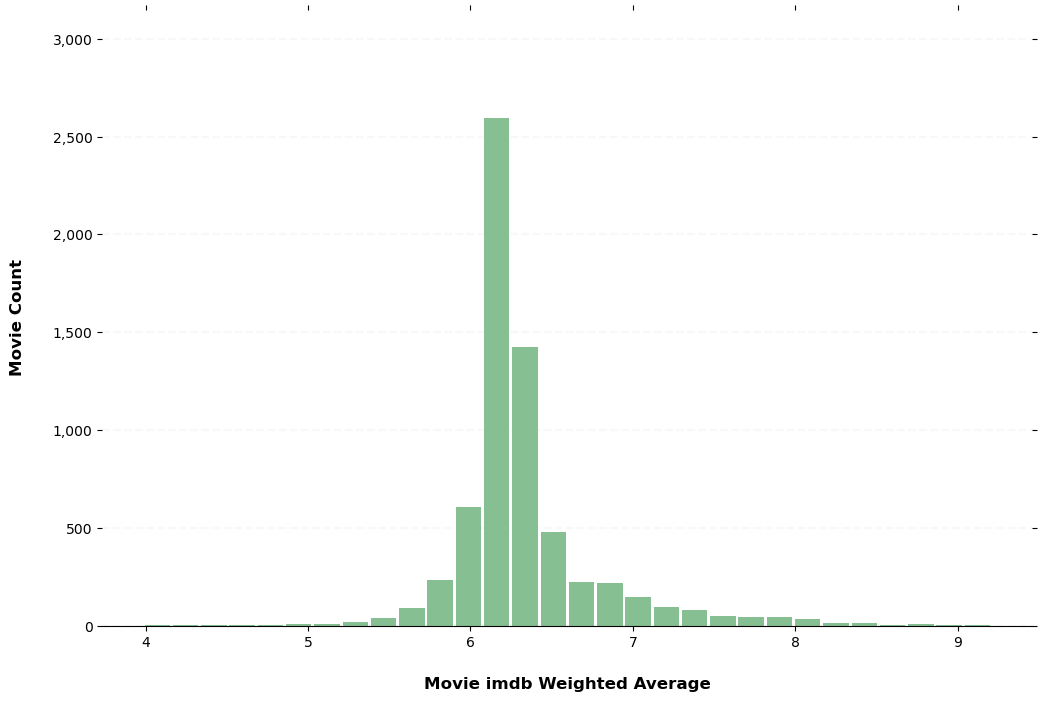

In [41]:
ax = wiki_american_british.hist(column='Weighted_average', bins=30, grid=False, figsize=(12,8), color='#86bf91', zorder=2, rwidth=0.9)
ax = ax[0]
for x in ax:

    # Despine
    x.spines['right'].set_visible(False)
    x.spines['top'].set_visible(False)
    x.spines['left'].set_visible(False)

    # Switch off ticks
    x.tick_params(axis="both", which="both", bottom="off", top="off", labelbottom="on", left="off", right="off", labelleft="on")

    # Draw horizontal axis lines
    vals = x.get_yticks()
    for tick in vals:
        x.axhline(y=tick, linestyle='dashed', alpha=0.4, color='#eeeeee', zorder=1)

    # Remove title
    x.set_title("")

    # Set x-axis label
    x.set_xlabel("Movie imdb Weighted Average", labelpad=20, weight='bold', size=12)

    # Set y-axis label
    x.set_ylabel("Movie Count", labelpad=20, weight='bold', size=12)

    # Format y-axis label
    x.yaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter('{x:,g}'))

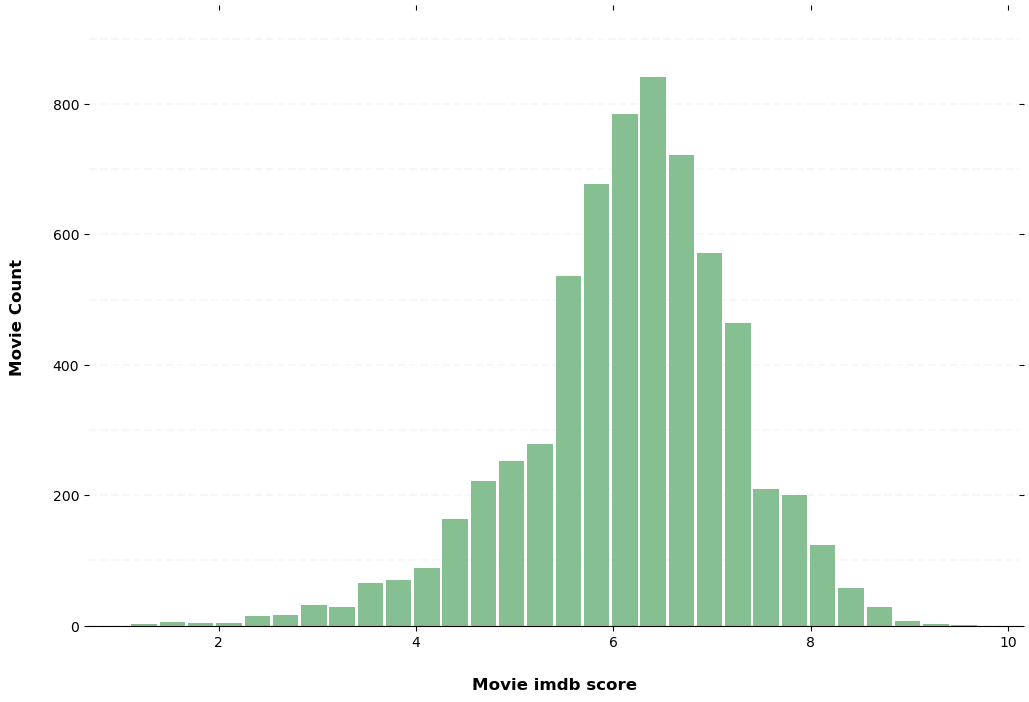

In [42]:
ax = wiki_american_british.hist(column='imdb_score', bins=30, grid=False, figsize=(12,8), color='#86bf91', zorder=2, rwidth=0.9)
ax = ax[0]
for x in ax:

    # Despine
    x.spines['right'].set_visible(False)
    x.spines['top'].set_visible(False)
    x.spines['left'].set_visible(False)

    # Switch off ticks
    x.tick_params(axis="both", which="both", bottom="off", top="off", labelbottom="on", left="off", right="off", labelleft="on")

    # Draw horizontal axis lines
    vals = x.get_yticks()
    for tick in vals:
        x.axhline(y=tick, linestyle='dashed', alpha=0.4, color='#eeeeee', zorder=1)

    # Remove title
    x.set_title("")

    # Set x-axis label
    x.set_xlabel("Movie imdb score", labelpad=20, weight='bold', size=12)

    # Set y-axis label
    x.set_ylabel("Movie Count", labelpad=20, weight='bold', size=12)

    # Format y-axis label
    x.yaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter('{x:,g}'))

In [43]:
wiki_american_british[wiki_american_british['Weighted_average'] < 5.0].shape

(19, 38)

In [44]:
wiki_american_british[wiki_american_british['imdb_score'] < 5.0].shape

(784, 38)

In [ ]:
wiki_american_british = wiki_american_british[wiki_american_british['imdb_score'] >= 6.0]

In [47]:
print("Lowest imdb score post drop weighted < 6.0 is...  " + str(wiki_american_british['imdb_score'].min()))

Lowest imdb score post drop weighted < 6.0 is...  1.1


In [45]:
wiki_american_british.to_csv('wiki_movies_mood_label_by_gpt-3.5-turbo_final.csv')

In [46]:
df = pd.read_csv('wiki_movies_mood_label_by_gpt-3.5-turbo_final.csv')

rating: 8.00 
votes:  100k

False    5898
True       69

rating: 7.00 
votes:  50k

False    5549
True       418


rating: 6.50
votes:  10k

False    4461
True     1506